This 68kbp VFC 1 vOTU was chosen as it was detected in 9 samples in the SPMP cohort.

It was aligned (query) against short-read contigs from *all* samples (subject) using blastn.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

hybcontig = 'TLL29_opera_contig_162838_provirus_247241_315985'; l = 70e3

df = pd.read_csv(
    f'../data/hybrid_vs_shortread_comparison/{hybcontig}-all_shortread_assemblies.tsv', sep='\t',
    names=['qseqid','sseqid','pident','length','mismatch','gapopen','qstart','qend','sstart','send','evalue','bitscore','qlen','slen']
)

Retain short-read contigs that align at 99.9% ANI over 99.9% coverage

In [2]:
thresh = 99.9

df['scov'] = df.length/df.slen*100
df1 = df.loc[(df.pident >= thresh) & (df.scov >= thresh)]

len(df1)

147

### Supplementary Fig. 6B: histogram of short-read contig lengths aligning to 68kbp hybrid vOTU

In [3]:
print(f'Longest short-read contig aligning to this vOTU = {df1.slen.max()}')

Longest short-read contig aligning to this vOTU = 27677


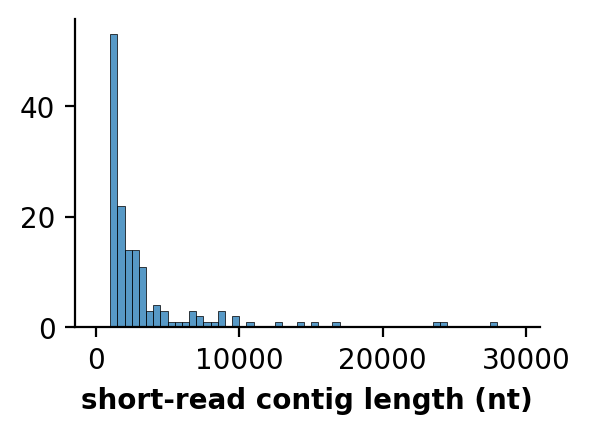

In [4]:
fig, ax = plt.subplots(figsize=(3,2), dpi=200)

sns.histplot(data=df1, x='slen', bins=np.arange(0,30e3,500), ax=ax)

plt.xlabel('short-read contig length (nt)', fontweight='bold')
plt.ylabel('')

sns.despine()

### Supplementary Fig. 6C: stacked histogram of short-read contig alignment start and end positions

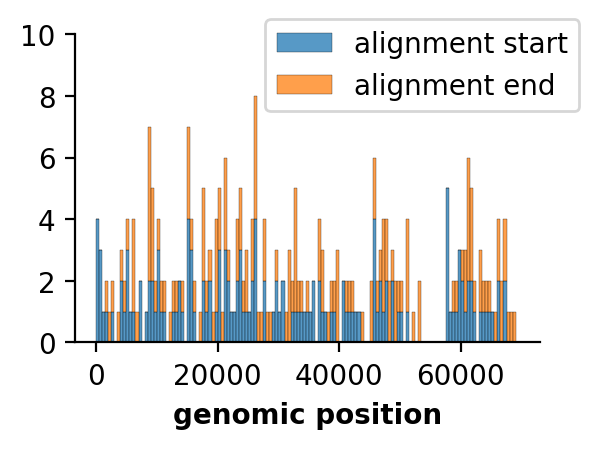

In [5]:
sns.set_palette('tab10')

start_coords = df1.qstart.tolist()
end_coords = df1.qend.tolist()

data = {
    'position': start_coords + end_coords,
    'type': ['start'] * len(start_coords) + ['end'] * len(end_coords)
}

fig, ax = plt.subplots(figsize=(3,2), dpi=200)

sns.histplot(data=data, x='position', hue='type', bins=np.arange(0,l,500), multiple='stack', hue_order=['end','start'], palette=['C1','C0'], ax=ax)

plt.xlabel('genomic position', fontweight='bold')
plt.ylabel('')
ax.legend(['alignment start','alignment end'], loc=(0.41,0.75))
plt.yticks([0,2,4,6,8,10])
# plt.yticks([0,1,2])

sns.despine()

### Supplementary Fig. 6D: histogram of short-read contig alignments over hybrid vOTU

In [6]:
def get_covered_bases(x):
    return list(range(x.qstart, x.qend + 1))

covered_coordinates = np.concatenate(df1.apply(lambda x: get_covered_bases(x), axis=1).tolist(), axis=0)

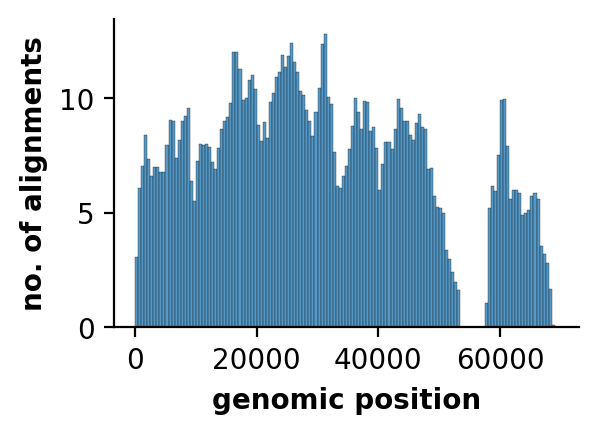

In [7]:
fig, ax = plt.subplots(figsize=(3,2), dpi=200)

sns.histplot(covered_coordinates, bins=np.arange(0,l,500), stat='frequency', ax=ax)

plt.xlabel('genomic position', fontweight='bold')
plt.ylabel('no. of alignments', fontweight='bold')

sns.despine()